<a href="https://colab.research.google.com/github/niha630/Customer_Behavior_Analysis/blob/main/Customer_Behavior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
# Data Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve

# Advanced tools
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

import joblib
import warnings
warnings.filterwarnings("ignore")

#  Load Dataset

In [2]:
import os
print(os.listdir("../data"))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Dataset Information

In [4]:
# Dataset Info
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Data Cleaning

In [5]:

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# Encode Categorical Variables

In [6]:

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

print("\nEncoded Dataset")
df.head()


Encoded Dataset


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


# Churn Rate Analysis

In [7]:
print("Churn Rate:", df["Churn"].mean())

df["Churn"].value_counts()

Churn Rate: 0.2653698707936959


Churn
0    5174
1    1869
Name: count, dtype: int64

# Exploratory Data Analysis

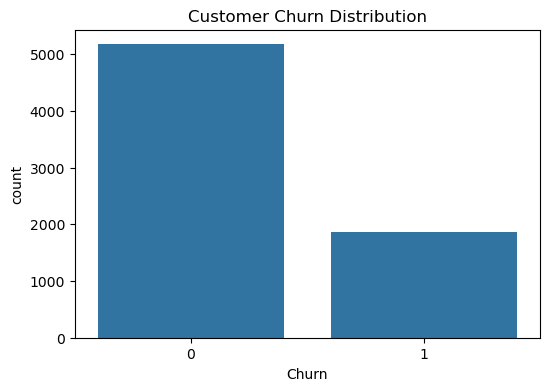

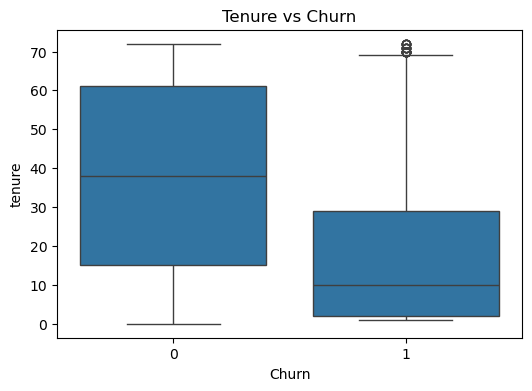

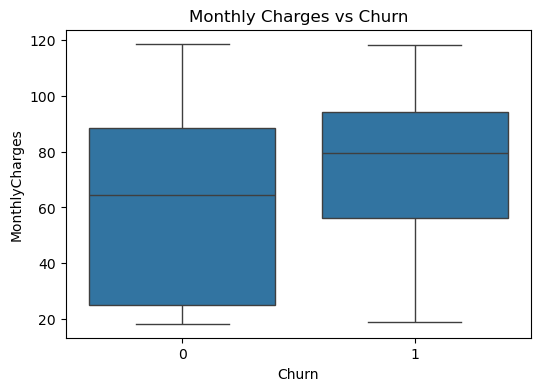

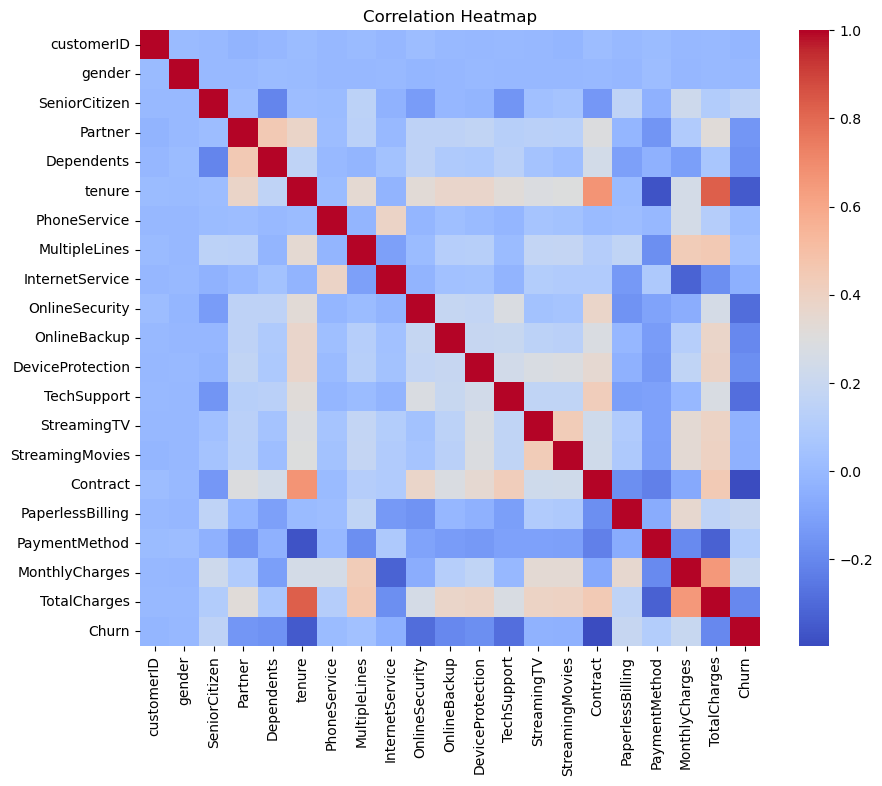

In [8]:
# churn distribution

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

# Tenure vs churn

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

# Monthly Charges vs Churn

plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Feature Selection

In [9]:
# Split Features and Target

X = df.drop("Churn", axis=1)

y = df["Churn"]

In [10]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Model Training

In [12]:
# Logistic Regression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

# Decision Tree

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

# Random Forest

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

# KNN

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:",
      accuracy_score(y_test, y_pred_knn))

Logistic Regression Accuracy: 0.8161816891412349
Decision Tree Accuracy: 0.7246273953158269
Random Forest Accuracy: 0.7934705464868701
KNN Accuracy: 0.7672107877927609


# Accuracy Comparison

In [13]:
results = pd.DataFrame({

"Model":["Logistic Regression","Decision Tree",
"Random Forest","KNN"],

"Accuracy":[
accuracy_score(y_test,y_pred_lr),
accuracy_score(y_test,y_pred_dt),
accuracy_score(y_test,y_pred_rf),
accuracy_score(y_test,y_pred_knn)

]

})

results

,Model,Accuracy
0,Logistic Regression,0.816182
1,Decision Tree,0.724627
2,Random Forest,0.793471
3,KNN,0.767211


# Visualization

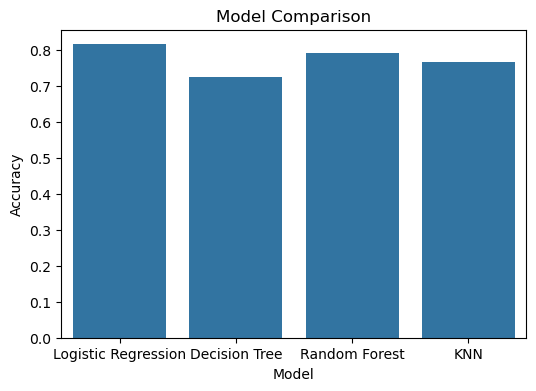

In [14]:
plt.figure(figsize=(6,4))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Model Comparison")

plt.show()

# Hyperparameter Tuning

In [15]:
param_grid = {

"n_estimators":[100,200],

"max_depth":[5,10,15]

}

grid = GridSearchCV(RandomForestClassifier(),
param_grid, cv=5)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 200}


 # Cross Validation

In [16]:
scores = cross_val_score(best_model, X, y, cv=5)

print("Cross Validation Score:", scores.mean())

Cross Validation Score: 0.7985255097103038


# Confusion Matrix

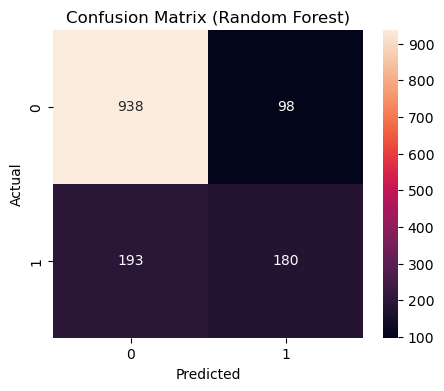

In [17]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d')  # <-- add fmt='d'

plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Report

In [18]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.48      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# Feature Importance

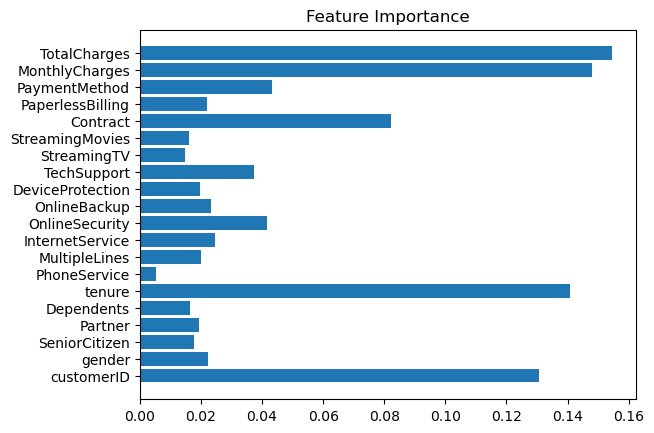

In [19]:
importances = rf.feature_importances_

features = X.columns

plt.barh(features, importances)

plt.title("Feature Importance")

plt.show()


# ROC Curve

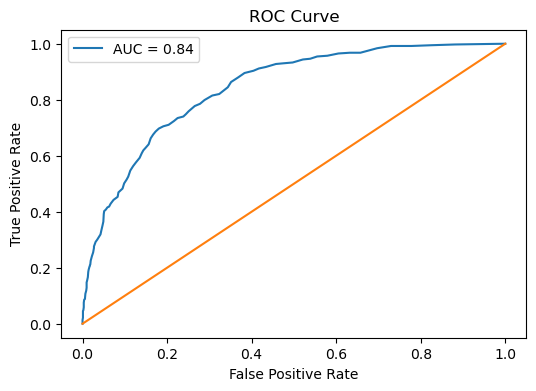

In [20]:


y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


# Precision Recall Curve

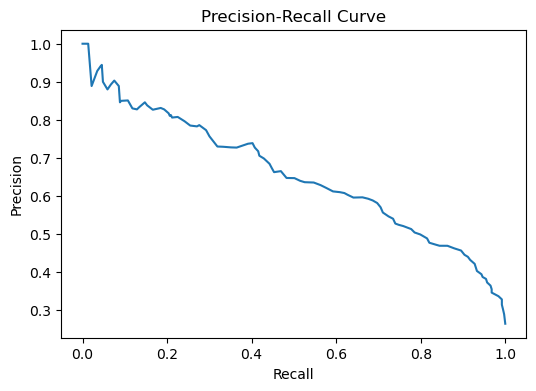

In [21]:


precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [22]:
# save best model

joblib.dump(best_model, "customer_churn_model.pkl")

['customer_churn_model.pkl']

In [23]:
# Predict Churn for New Customer

# create empty row with correct columns
new_customer_df = pd.DataFrame(columns=X.columns)

# fill values
new_customer_df.loc[0] = [
1,0,1,0,12,1,0,1,0,1,0,0,1,1,0,1,2,70,840,0
]

# scale
new_customer_scaled = scaler.transform(new_customer_df)

# predict
prediction = lr.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Prediction: Customer will churn")
else:
    print("Prediction: Customer will stay")

Prediction: Customer will churn
